## Importing Libraries

In [38]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

### Loading Model

In [29]:
model = tf.keras.models.load_model('resnet50_model.keras')

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_1 (Dense)             (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 predictions (Dense)         (None, 11)                2827      
                                                                 
Total params: 24115083 (91.99 MB)
Trainable params: 527371 (2.01 MB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


#### Visualising Single Image of Test set 

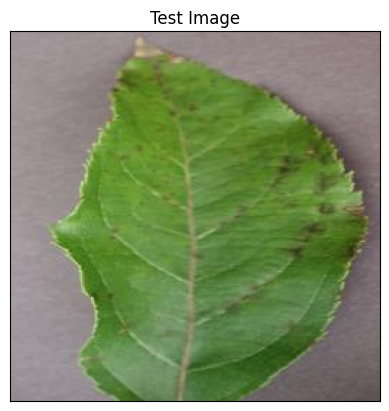

In [31]:
import cv2
image_path=r"test/AppleScab1.JPG"
# Reading Image
img = cv2.imread(image_path) # by Default BGR
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) # Convert BGR img to RGB

# Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [ ]:
# Preprocessing
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128)) # [(128,128)-CNN],[(224,224)-resnet50] 

input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) # Conveert single image to a batch
print(input_arr.shape)

(1, 224, 224, 3)


In [33]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 468ms/step


(array([[1.95080992e-02, 1.10031600e-04, 9.55525517e-01, 3.42428870e-03,
         4.98196596e-06, 1.52449611e-05, 2.48622120e-04, 8.83732107e-04,
         1.04244555e-05, 2.38928294e-07, 2.02687848e-02]], dtype=float32),
 (1, 11))

In [34]:
result_index = np.argmax(prediction)
result_index

2

In [35]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy']

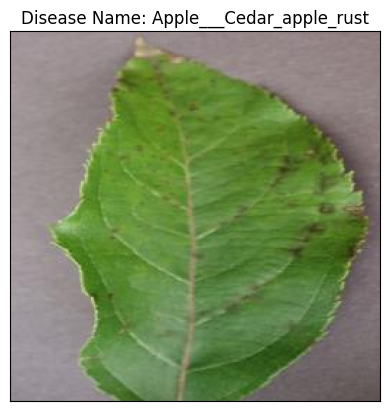

In [36]:
# Display Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [37]:
model_prediction

'Apple___Cedar_apple_rust'